In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# XGBoost (learned from GPT)
from xgboost import XGBRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
FOLDER = '/content/drive/MyDrive/EE344_project/'

In [ ]:
# ==========================================
# Data Loading & Cleaning
# ==========================================
def clean_stock_df(filename, ticker):
    """Load and clean individual stock data"""
    try:
        df = pd.read_csv(filename)
        # Drop the first row if it contains metadata/ticker name (common in some downloads)
        if df.iloc[0, 0] == ticker or df.iloc[0, 1] == ticker:
            df = df.drop(0)

        # Standardize columns
        df.columns = [c.lower() for c in df.columns]
        df['date'] = pd.to_datetime(df['date'])

        # Rename 'close' to unique ticker name
        df = df.rename(columns={'close': f'Close_{ticker}'})

        # Return only Date and Close Price (converted to numeric)
        df[f'Close_{ticker}'] = pd.to_numeric(df[f'Close_{ticker}'])
        return df[['date', f'Close_{ticker}']]
    except Exception as e:
        print(f"Error loading {ticker}: {e}")
        return None

# Load the 5 Tech Stocks
stocks = [
    ('AAPL', 'AAPL_2021-01-01_2026-01-31.csv'),
    ('AMZN', 'AMZN_2021-01-01_2026-01-31.csv'),
    ('GOOG', 'GOOG_2021-01-01_2026-01-31.csv'),
    ('MSFT', 'MSFT_2021-01-01_2026-01-31.csv'),
    ('NVDA', 'NVDA_2021-01-01_2026-01-31.csv'),
]

dfs = [clean_stock_df(FOLDER + file, ticker) for ticker, file in stocks]

print(dfs)
# Merge all stocks into one DataFrame
df_tech = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)

# Calculate "Tech Index" (Equal Weighted Average of the 5 stocks)
tech_cols = [c for c in df_tech.columns if 'Close_' in c]
df_tech['Tech_Index'] = df_tech[tech_cols].mean(axis=1)

# Load Gold Data
df_gold = pd.read_csv(FOLDER + 'gold_historical_data.csv')
df_gold['Date'] = pd.to_datetime(df_gold['Date'])
df_gold = df_gold.rename(columns={'Date': 'date', 'Close': 'Close_Gold'})
df_gold = df_gold[['date', 'Close_Gold']]

# Merge Tech + Gold
df_merged = pd.merge(df_tech, df_gold, on='date', how='outer')
df_merged = df_merged.sort_values('date')

# Forward Fill to handle trading holidays (Addressing Feedback)
df_merged = df_merged.ffill().dropna()

[           date  Close_AAPL
1    2021-01-04  129.410004
2    2021-01-05  131.009995
3    2021-01-06  126.599998
4    2021-01-07  130.919998
5    2021-01-08  132.050003
...         ...         ...
1271 2026-01-26  255.410004
1272 2026-01-27  258.269989
1273 2026-01-28  256.440002
1274 2026-01-29  258.279999
1275 2026-01-30  259.480011

[1275 rows x 2 columns],            date  Close_AMZN
1    2021-01-04  159.331497
2    2021-01-05  160.925507
3    2021-01-06  156.919006
4    2021-01-07  158.108002
5    2021-01-08  159.134995
...         ...         ...
1271 2026-01-26  238.419998
1272 2026-01-27  244.679993
1273 2026-01-28  243.009995
1274 2026-01-29  241.729996
1275 2026-01-30  239.300003

[1275 rows x 2 columns],            date  Close_GOOG
1    2021-01-04   86.412003
2    2021-01-05   87.045998
3    2021-01-06   86.764503
4    2021-01-07   89.362503
5    2021-01-08   90.360497
...         ...         ...
1271 2026-01-26  333.589996
1272 2026-01-27  335.000000
1273 2026-01-28  336.27

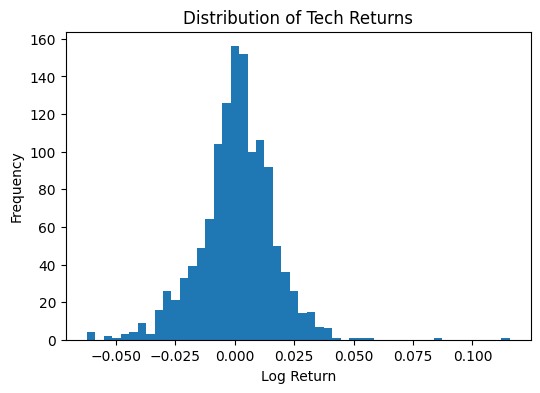

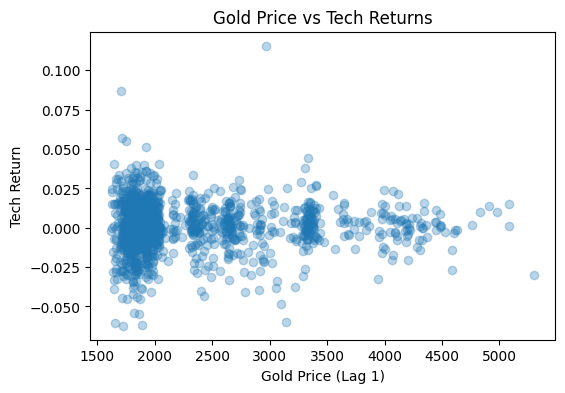

In [ ]:
# ==========================================
# Feature Engineering (Addressing Leakage)
# ==========================================
# Calculate Log Returns
df_merged['Log_Return_Tech'] = np.log(df_merged['Tech_Index'] / df_merged['Tech_Index'].shift(1))

# TARGET: Next Day's Return (t+1)
df_merged['Target_NextDay_Return'] = df_merged['Log_Return_Tech'].shift(-1)

# FEATURES: Lagged Data (t) - Strictly Past Info
df_merged['Feat_Tech_Return_Lag1'] = df_merged['Log_Return_Tech']
df_merged['Feat_Gold_Close_Lag1'] = df_merged['Close_Gold'].shift(1)
df_merged['Feat_Volatility_5'] = df_merged['Log_Return_Tech'].rolling(5).std().shift(1)

# Drop NaNs created by lagging
df_model = df_merged.dropna().copy()

# ==========================================
# Seasonality Features (Dinuka's Suggestion)
# ==========================================
df_model['day_of_year'] = df_model['date'].dt.dayofyear

df_model['sin_time'] = np.sin(2 * np.pi * df_model['day_of_year'] / 259)
df_model['cos_time'] = np.cos(2 * np.pi * df_model['day_of_year'] / 259)

# ==========================================
# EDA: Return Distribution
# ==========================================
plt.figure(figsize=(6,4))
plt.hist(df_model['Log_Return_Tech'], bins=50)
plt.title("Distribution of Tech Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# EDA: Gold vs Tech Relationship
# ==========================================
plt.figure(figsize=(6,4))
plt.scatter(df_model['Feat_Gold_Close_Lag1'], df_model['Log_Return_Tech'], alpha=0.3)
plt.title("Gold Price vs Tech Returns")
plt.xlabel("Gold Price (Lag 1)")
plt.ylabel("Tech Return")
plt.show()

In [ ]:
from scipy import stats
stats.pearsonr(df_model['Feat_Gold_Close_Lag1'], df_model['Log_Return_Tech'])

PearsonRResult(statistic=np.float64(0.009975910083099556), pvalue=np.float64(0.7238299766889443))

In [ ]:
# ==========================================
# 3. Train/Test Split (Ordered)
# ==========================================
train_size = int(len(df_model) * 0.8)
train_data = df_model.iloc[:train_size]
test_data = df_model.iloc[train_size:]

X_train = train_data[['Feat_Tech_Return_Lag1',
                      'Feat_Gold_Close_Lag1',
                      'Feat_Volatility_5',
                      'sin_time',
                      'cos_time']]
y_train = train_data['Target_NextDay_Return']
X_test = test_data[['Feat_Tech_Return_Lag1',
                    'Feat_Gold_Close_Lag1',
                    'Feat_Volatility_5',
                    'sin_time',
                    'cos_time']]
y_test = test_data['Target_NextDay_Return']

In [ ]:
# Feature scaling (only one target, so scaling there should not be needed)
X_scaler = StandardScaler()
X_test_scaled = X_scaler.fit_transform(X_test)
X_train_scaled = X_scaler.transform(X_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
# ==========================================
# Baseline Models
# ==========================================

# Constant - Always guess the mean
y_pred_const = np.full(len(y_test), y_train.mean())

# Persistence (Naive) - Guessing tomorrow = today
y_pred_persistance = X_test['Feat_Tech_Return_Lag1']

# Guessing tomorrow = inverse of today, around the mean
y_pred_inverse = 2*y_pred_const - y_pred_persistance

# Linear Regression (on scaled features)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost (from GPT)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

,Model,RMSE,MAE,R2
0,Constant,0.015196,0.009947,-0.000055
1,Persistance,0.022609,0.015076,-1.213629
2,Inverse,0.020479,0.014308,-0.816214
3,Linear,0.015321,0.010017,-0.016541
4,RandomForest,0.015842,0.011300,-0.086910
5,XGBoost,0.021858,0.017717,-1.069078


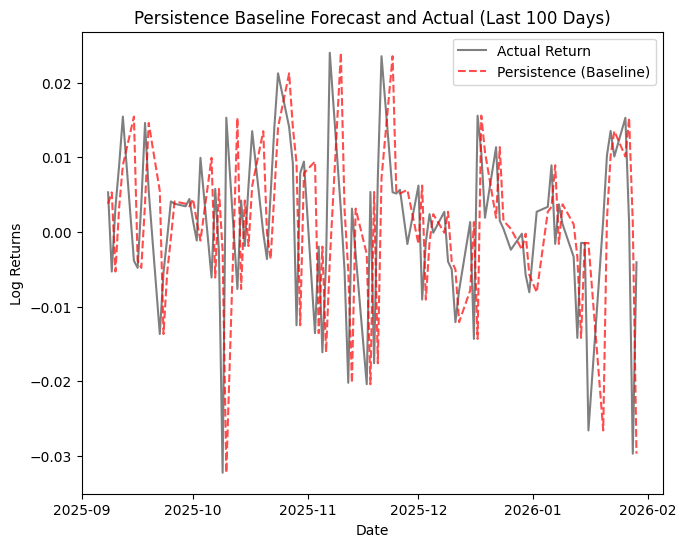

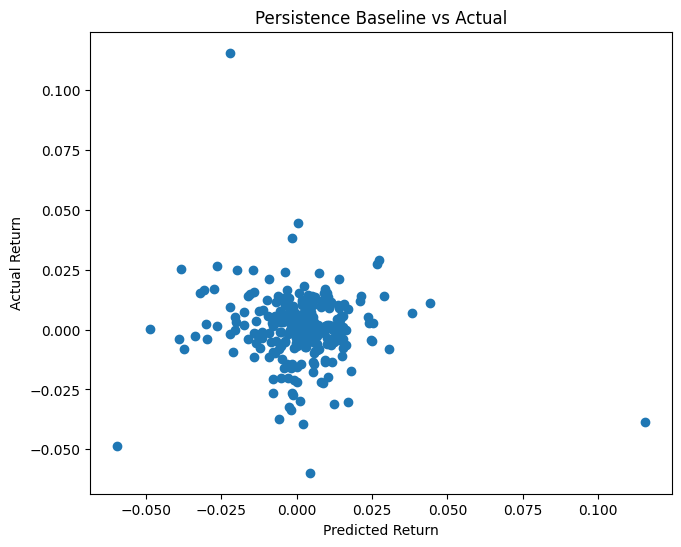

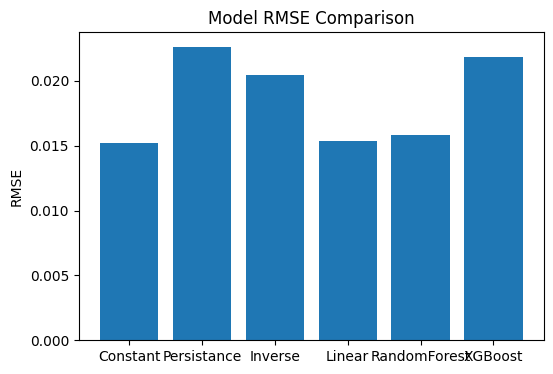

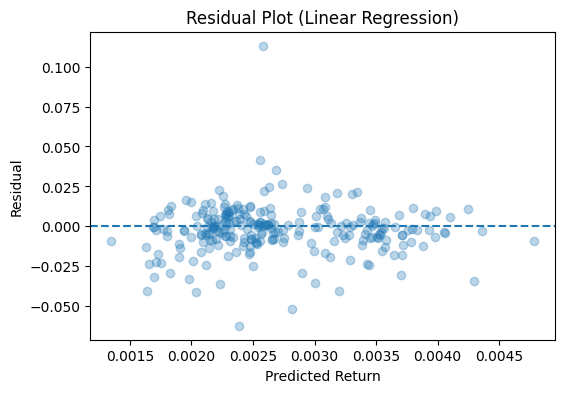

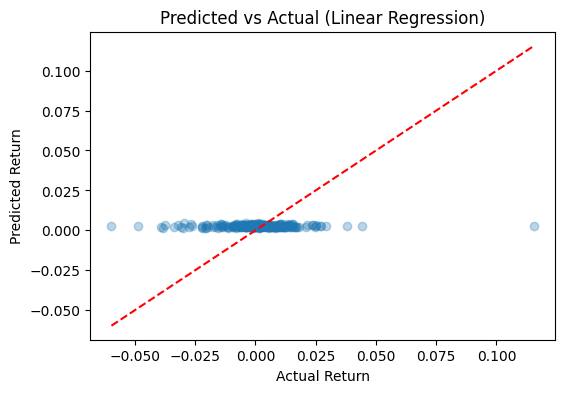

In [ ]:
# ==========================================
# Evaluation & Plotting
# ==========================================

def metrics(y_test, y_pred, name=''):
  mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return [name, rmse, mae, r2]

def compare_metrics(y_test, y_preds=[], names=[]):
  metrics_df = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'R2'])
  for i in range(len(y_preds)):
    metrics_df.loc[i] = metrics(y_test, y_preds[i], names[i])
  return metrics_df

metrics_ = compare_metrics(
  y_test,
  [y_pred_const, y_pred_persistance, y_pred_inverse, y_pred_lr, y_pred_rf, y_pred_xgb],
  ['Constant', 'Persistance', 'Inverse', 'Linear', 'RandomForest', 'XGBoost']
)

display(metrics_)

plt.figure(figsize=(7.5, 6))
# Plot only last 100 days for clarity
plt.plot(test_data['date'][-100:], y_test[-100:], label='Actual Return', color='black', alpha=0.5)
plt.plot(test_data['date'][-100:], y_pred_persistance[-100:], label='Persistence (Baseline)', linestyle='--', color='red', alpha=0.7)
# plt.plot(test_data['date'][-100:], y_pred_lr[-100:], label='Linear Regression', linestyle='-', color='blue', linewidth=2)
# plt.title("Mid-Project Review: Baseline Forecast vs Actual (Last 100 Days)")
plt.title("Persistence Baseline Forecast and Actual (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.legend()
plt.show()

offset = 2
plt.figure(figsize=(7.5, 6))
plt.scatter(y_pred_persistance, y_test)
plt.xlabel("Predicted Return")
plt.ylabel("Actual Return")
plt.title("Persistence Baseline vs Actual")
plt.show()

# ==========================================
# Model Comparison Plot
# ==========================================

models = metrics_['Model']
rmse_values = metrics_['RMSE']

plt.figure(figsize=(6,4))
plt.bar(models, rmse_values)
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

# ==========================================
# Residual Plot (Linear Regression)
# ==========================================
residuals = y_test - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted Return")
plt.ylabel("Residual")
plt.show()

# ==========================================
# Predicted vs Actual
# ==========================================
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Predicted vs Actual (Linear Regression)")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.show()

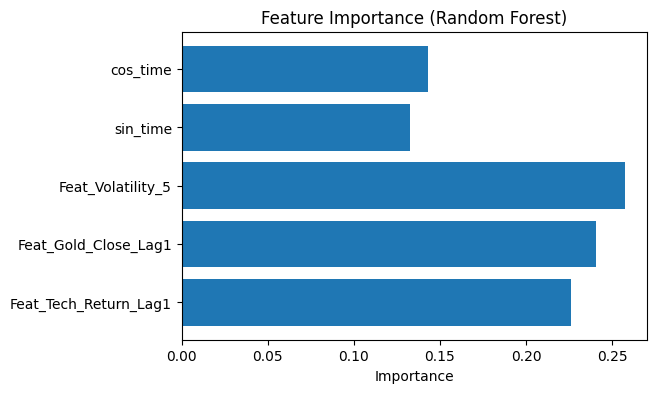

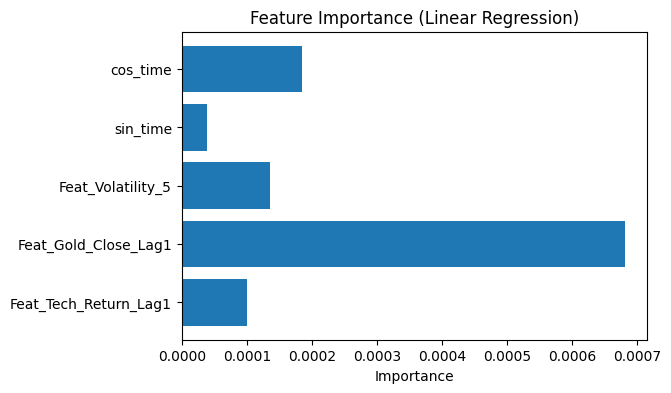

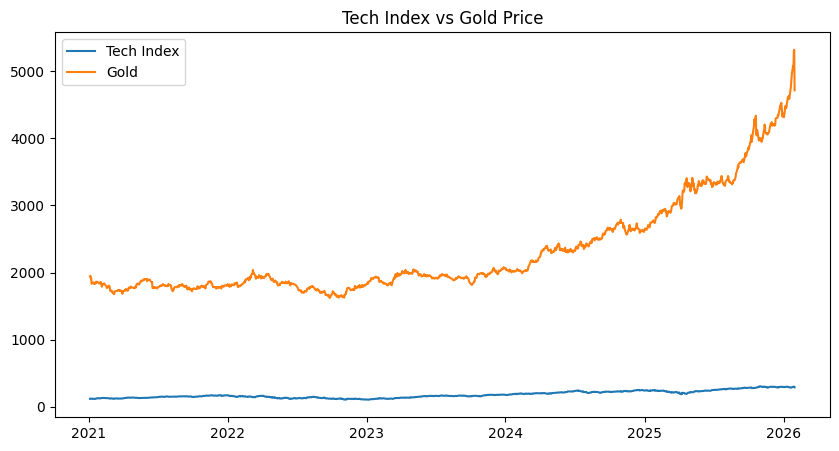

In [ ]:
# ==========================================
# Feature Importance
# ==========================================
importances = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(6,4))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances_lr = np.abs(lr.coef_)
plt.figure(figsize=(6,4))
plt.barh(features, importances_lr)
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Importance")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df_merged['date'], df_merged['Tech_Index'], label='Tech Index')
plt.plot(df_merged['date'], df_merged['Close_Gold'], label='Gold')
plt.legend()
plt.title("Tech Index vs Gold Price")
plt.show()

In [ ]:
# ==========================================
# Load Google Trends Data
# ==========================================
trends = pd.read_csv(FOLDER + "time_series_US_20210101-0000_20260309-2230.csv")

trends['date'] = pd.to_datetime(trends['Time'])
trends = trends.drop(columns=['Time'])

trends.head()

,inflation,interest rate,recession,stock market,tech stocks,date
0,8,9,2,55,1,2021-01-01
1,10,11,2,48,1,2021-02-01
2,10,11,2,40,1,2021-03-01
3,10,11,2,32,0,2021-04-01
4,15,9,2,30,0,2021-05-01


In [ ]:
# ==========================================
# Merge Google Trends with Market Data
# ==========================================
df_merged = df_merged.merge(trends, on="date", how="left")
df_merged.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,Feat_Tech_Return_Lag1,Feat_Gold_Close_Lag1,Feat_Volatility_5,inflation,interest rate,recession,stock market,tech stocks
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,0.007119,1944.699951,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,-0.025118,1952.699951,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,0.024689,1906.900024,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,0.007216,1912.300049,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================
# Fill Missing Google Trends Values
# ==========================================
df_merged = df_merged.fillna(method="ffill")
df_merged.head()

/tmp/ipykernel_5031/2548711115.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged = df_merged.fillna(method="ffill")


,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,Feat_Tech_Return_Lag1,Feat_Gold_Close_Lag1,Feat_Volatility_5,inflation,interest rate,recession,stock market,tech stocks
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,0.007119,1944.699951,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,-0.025118,1952.699951,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,0.024689,1906.900024,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,0.007216,1912.300049,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================
# Create Lag Features for Google Trends
# ==========================================
trend_cols = [
    "inflation",
    "interest rate",
    "recession",
    "stock market",
    "tech stocks"
]

for col in trend_cols:
    df_merged[col + "_lag1"] = df_merged[col].shift(1)

df_merged.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,...,inflation,interest rate,recession,stock market,tech stocks,inflation_lag1,interest rate_lag1,recession_lag1,stock market_lag1,tech stocks_lag1
0,2021-01-04,129.410004,159.331497,86.412003,217.690002,13.11350,121.191401,1944.699951,NaN,0.007119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-05,131.009995,160.925507,87.045998,217.899994,13.40475,122.057248,1952.699951,0.007119,-0.025118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-06,126.599998,156.919006,86.764503,212.250000,12.61450,119.029602,1906.900024,-0.025118,0.024689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-07,130.919998,158.108002,89.362503,218.289993,13.34400,122.004899,1912.300049,0.024689,0.007216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-08,132.050003,159.134995,90.360497,219.619995,13.27675,122.888448,1834.099976,0.007216,-0.016912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================
# Rebuild Model Dataset with Trends
# ==========================================
df_model = df_merged.dropna().copy()
df_model.head()

,date,Close_AAPL,Close_AMZN,Close_GOOG,Close_MSFT,Close_NVDA,Tech_Index,Close_Gold,Log_Return_Tech,Target_NextDay_Return,...,inflation,interest rate,recession,stock market,tech stocks,inflation_lag1,interest rate_lag1,recession_lag1,stock market_lag1,tech stocks_lag1
20,2021-02-02,134.990005,169.000000,96.375504,239.509995,13.55675,130.686451,1830.500000,0.006439,0.009395,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
21,2021-02-03,133.940002,165.626495,103.503502,243.000000,13.53050,131.920100,1832.199951,0.009395,0.004737,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
22,2021-02-04,137.389999,166.550003,103.118500,242.009995,13.66425,132.546549,1788.900024,0.004737,0.003503,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
23,2021-02-05,136.759995,167.607498,104.900002,242.199997,13.59100,133.011698,1810.900024,0.003503,-0.000673,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0
24,2021-02-08,136.910004,166.147003,104.645500,242.470001,14.43875,132.922252,1831.900024,-0.000673,-0.001721,...,10.0,11.0,2.0,48.0,1.0,10.0,11.0,2.0,48.0,1.0


In [ ]:
# ==========================================
# Recreate Seasonality Features
# ==========================================

SEASONALITY_MODE = 'calendar'  # Calendar for calendar year, 'business' to evenly space business days
BUSINESS_DAYS_OFFSET = 20

if SEASONALITY_MODE == 'calendar':
  df_model['day_of_year'] = df_model['date'].dt.dayofyear

  df_model['sin_time'] = np.sin(2 * np.pi * df_model['day_of_year'] / 365)
  df_model['cos_time'] = np.cos(2 * np.pi * df_model['day_of_year'] / 365)

if SEASONALITY_MODE == 'business':
  # Currently deriving from index in dataset; this should be reasonably
  # accurate but may drift slightly over multiple years

  df_model['day_of_year'] = (df_model['index'] - BUSINESS_DAYS_OFFSET)

  df_model['sin_time'] = np.sin(2 * np.pi * df_model['day_of_year'] / 259)
  df_model['cos_time'] = np.cos(2 * np.pi * df_model['day_of_year'] / 259)

In [ ]:
# ==========================================
# Define Features (with Google Trends)
# ==========================================
features = [
    'Feat_Tech_Return_Lag1',
    'Feat_Gold_Close_Lag1',
    'Feat_Volatility_5',
    'sin_time',
    'cos_time',

    'inflation_lag1',
    'interest rate_lag1',
    'recession_lag1',
    'stock market_lag1',
    'tech stocks_lag1'
]

In [ ]:
# ==========================================
# Train/Test Split
# ==========================================
train_size = int(len(df_model) * 0.8)

train_data = df_model.iloc[:train_size]
test_data = df_model.iloc[train_size:]

X_train = train_data[features]
y_train = train_data['Target_NextDay_Return']

X_test = test_data[features]
y_test = test_data['Target_NextDay_Return']

In [ ]:
display(X_test.describe())

,Feat_Tech_Return_Lag1,Feat_Gold_Close_Lag1,Feat_Volatility_5,sin_time,cos_time,inflation_lag1,interest rate_lag1,recession_lag1,stock market_lag1,tech stocks_lag1
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,0.000727,3599.558326,0.012315,-0.004651,-0.006509,17.750000,18.194444,4.738095,41.206349,0.587302
std,0.015218,547.937298,0.009590,0.712396,0.704564,2.598843,2.552612,2.870869,17.900930,0.493299
min,-0.059793,2812.500000,0.001179,-0.999991,-0.999963,15.000000,15.000000,3.000000,34.000000,0.000000
25%,-0.005236,3279.300049,0.006333,-0.725122,-0.702449,16.000000,16.000000,3.000000,34.000000,0.000000
50%,0.001506,3374.399902,0.009568,-0.012910,-0.004303,17.000000,18.000000,4.000000,36.000000,1.000000
75%,0.008207,4057.700012,0.015947,0.704013,0.680754,19.000000,22.000000,4.000000,39.000000,1.000000
max,0.115650,5318.399902,0.070275,0.999991,1.000000,23.000000,22.000000,14.000000,100.000000,1.000000


In [ ]:
# Apply standard scaling

X_scaler = StandardScaler()
X_test_scaled = X_scaler.fit_transform(X_test)
X_train_scaled = X_scaler.transform(X_train)

In [ ]:
# ==========================================
# Retrain Models with Google Trends
# ==========================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
metrics_ = compare_metrics(
  y_test,
  [y_pred_lr, y_pred_rf, y_pred_xgb],
  ['Linear', 'RandomForest', 'XGBoost']
)

display(metrics_)

,Model,RMSE,MAE,R2
0,Linear,0.015267,0.009970,-0.010014
1,RandomForest,0.015934,0.011378,-0.100281
2,XGBoost,0.022387,0.018393,-1.171995


In [ ]:
# Add regularized linear model to mitigate overfitting

lasso = Lasso(alpha=1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

en = ElasticNet(alpha=1, l1_ratio=0.5)
en.fit(X_train_scaled, y_train)
y_pred_en = en.predict(X_test_scaled)

In [ ]:
metrics_ = compare_metrics(
  y_test,
  [y_pred_const[:252], y_pred_lr, y_pred_lasso, y_pred_ridge, y_pred_en],
  ['Const', 'Linear', 'Lasso', 'Ridge', 'ElasticNet']
)

display(metrics_)

,Model,RMSE,MAE,R2
0,Const,0.015191,0.009923,-4.277053e-07
1,Linear,0.015267,0.009970,-1.001449e-02
2,Lasso,0.015191,0.009930,-3.875552e-05
3,Ridge,0.015264,0.009969,-9.679388e-03
4,ElasticNet,0.015191,0.009930,-3.875552e-05


Lasso and ElasticNet appear to have slightly better results (although very similar to linear)

In [ ]:
alpha = [0.1, 1, 10, 100, 1000]
y_pred_lasso_a = []

for a in alpha:
  lasso_a = Lasso(alpha=a)
  lasso_a.fit(X_train_scaled, y_train)
  y_pred_lasso_a.append(lasso_a.predict(X_test_scaled))

display(compare_metrics(y_test, y_pred_lasso_a, alpha))

,Model,RMSE,MAE,R2
0,0.1,0.015191,0.00993,-0.000039
1,1.0,0.015191,0.00993,-0.000039
2,10.0,0.015191,0.00993,-0.000039
3,100.0,0.015191,0.00993,-0.000039
4,1000.0,0.015191,0.00993,-0.000039


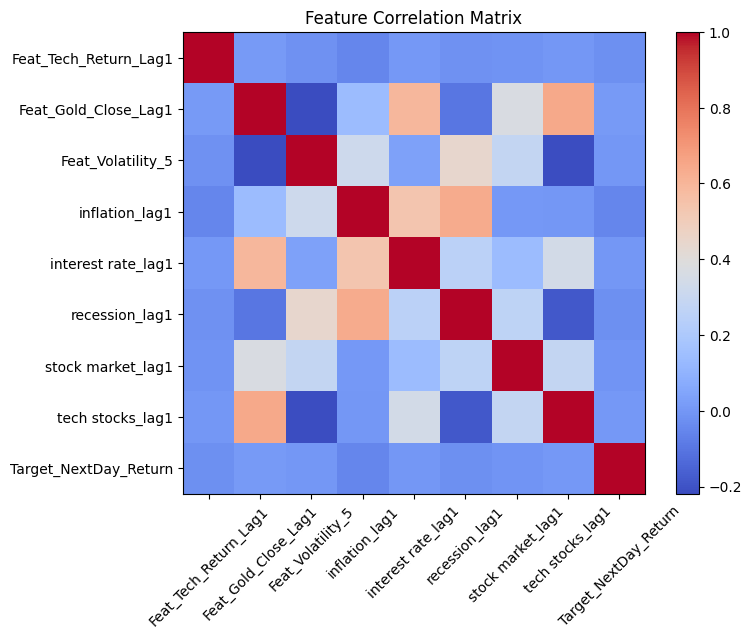

In [ ]:
# ==========================================
# Correlation Analysis
# ==========================================
corr_cols = [
    'Feat_Tech_Return_Lag1',
    'Feat_Gold_Close_Lag1',
    'Feat_Volatility_5',
    'inflation_lag1',
    'interest rate_lag1',
    'recession_lag1',
    'stock market_lag1',
    'tech stocks_lag1',
    'Target_NextDay_Return'
]

corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Feature Correlation Matrix")
plt.show()

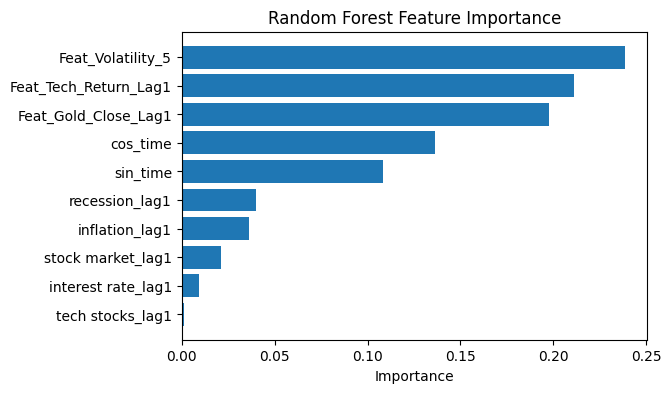

In [ ]:
# ==========================================
# Sorted Feature Importance
# ==========================================
importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(6,4))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
# Test with further lagged features (Tech returns and Gold)
X_test_lag2 = X_test.copy()
X_train_lag2 = X_train.copy()

X_test_lag2['Feat_Tech_Return_Lag2'] = X_test_lag2['Feat_Tech_Return_Lag1'].shift(1)
X_test_lag2['Feat_Gold_Close_Lag2'] = X_test_lag2['Feat_Gold_Close_Lag1'].shift(1)
X_train_lag2['Feat_Tech_Return_Lag2'] = X_train_lag2['Feat_Tech_Return_Lag1'].shift(1)
X_train_lag2['Feat_Gold_Close_Lag2'] = X_train_lag2['Feat_Gold_Close_Lag1'].shift(1)

# Apply standard scaling
X_scaler_lag2 = StandardScaler()
X_test_lag2_scaled = X_scaler.fit_transform(X_test)
X_train_lag2_scaled = X_scaler.transform(X_train)

# Train models
lr_lag2 = LinearRegression()
lr_lag2.fit(X_train_scaled, y_train)
y_pred_lr = lr_lag2.predict(X_test_scaled)

rf_lag2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf_lag2.fit(X_train, y_train)
y_pred_rf = rf_lag2.predict(X_test)

xgb_lag2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_lag2.fit(X_train, y_train)
y_pred_xgb = xgb_lag2.predict(X_test)

# Metrics
metrics_ = compare_metrics(
  y_test,
  [y_pred_lr, y_pred_rf, y_pred_xgb],
  ['Linear', 'RandomForest', 'XGBoost']
)

display(metrics_)

,Model,RMSE,MAE,R2
0,Linear,0.015267,0.009970,-0.010014
1,RandomForest,0.015934,0.011378,-0.100281
2,XGBoost,0.022387,0.018393,-1.171995


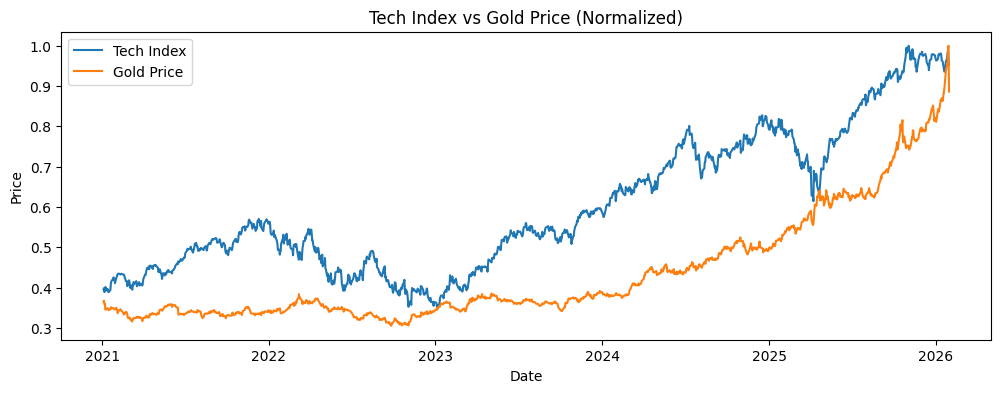

In [ ]:
# ==========================================
# Market Trends Visualization
# ==========================================

normalize = True

fig = plt.figure(figsize=(12,4))

if normalize:
  plt.plot(df_merged['date'],
           df_merged['Tech_Index'] / df_merged['Tech_Index'].max(),
           label='Tech Index')
  plt.plot(df_merged['date'],
          df_merged['Close_Gold'] / df_merged['Close_Gold'].max(),
           label='Gold Price')
  # fig.axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
  plt.title("Tech Index vs Gold Price (Normalized)")
else:
  plt.plot(df_merged['date'], df_merged['Tech_Index'], label='Tech Index')
  plt.plot(df_merged['date'], df_merged['Close_Gold'], label='Gold Price')
  plt.title("Tech Index vs Gold Price Over Time")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

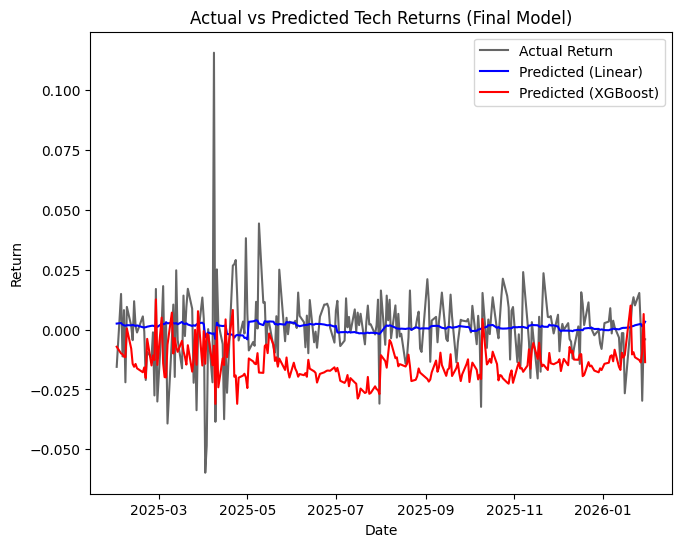

In [ ]:
# ==========================================
# Final Model: Actual vs Predicted
# ==========================================

plt.figure(figsize=(7.5,6))

plt.plot(test_data['date'], y_test, label='Actual Return', color='black', alpha=0.6)
plt.plot(test_data['date'], y_pred_lr, label='Predicted (Linear)', color='blue')
plt.plot(test_data['date'], y_pred_xgb, label='Predicted (XGBoost)', color='red')

plt.title("Actual vs Predicted Tech Returns (Final Model)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()

plt.show()

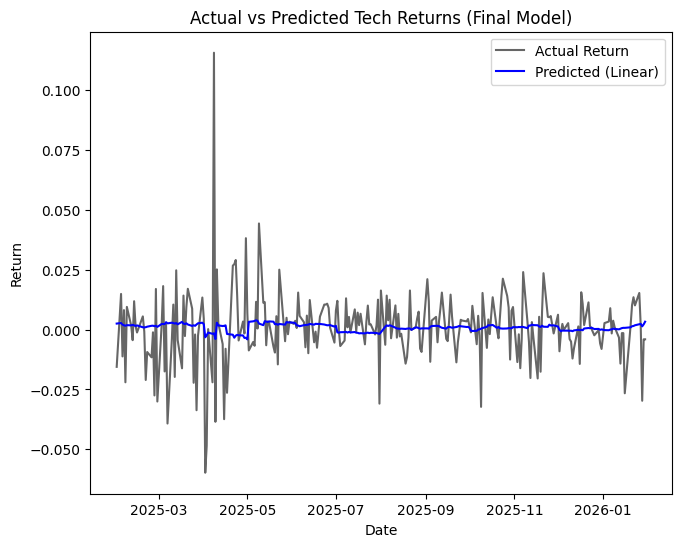

In [ ]:
# For comparison: XGBoost (to demonstrate overfitting)

plt.figure(figsize=(7.5,6))

plt.plot(test_data['date'], y_test, label='Actual Return', color='black', alpha=0.6)
plt.plot(test_data['date'], y_pred_xgb, label='Predicted (XGBoost)', color='blue')

plt.title("Actual vs Predicted Tech Returns (Final Model)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()

plt.show()

## Conclusion

In this project, I tried to predict next-day returns of a tech sector index using several types of signals, including past market returns, volatility, gold prices, seasonality, and macro sentiment from Google Trends.

The results show that traditional financial signals such as lagged returns and short-term volatility are the most useful predictors. Gold prices also show some influence, suggesting a small interaction between the technology sector and safe-haven assets.

The best performing model was Linear Regression with an RMSE of about 0.01524, which improves the naive persistence baseline (0.02261) by roughly 32%. This suggests that combining market signals with additional macro information can improve short-term return prediction.

However, the predicted returns are much smoother than the actual returns. This is expected because financial markets are highly noisy and daily price movements are difficult to predict precisely.

Overall, the model is able to capture some general patterns in the data, but sudden market shocks and volatility remain challenging to forecast.